In [86]:
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
from folium.plugins import HeatMap
import random
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Bài 1

In [87]:
m = folium.Map(location=[10.761047, 106.668346], zoom_start=15)

folium.Marker(
    location=[10.761047, 106.668346],
    popup="<b>UEH Cơ sở B</b>",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(m)

folium.Marker([10.7675, 106.6692], popup="<b> Bệnh viện Nhi Đồng 1<br> 341 Sư Vạn Hạnh, Quận 10").add_to(m)
folium.Marker([10.7715, 106.6672], popup="Vạn Hạnh Mall</b> 11 Sư Vạn Hạnh, Quận 10").add_to(m)
folium.Marker([10.7565, 106.6613], popup="Hùng Vương Plaza</b> 126 Hồng Bàng, Quận 5").add_to(m)
folium.Marker([10.7622, 106.6605], popup="Co.opmart Lý Thường Kiệt</b> 497 Hòa Hảo, Quận 10").add_to(m)
folium.Marker([10.7620, 106.6670], popup="Công viên Hòa Bình</b> Phường 9, Quận 5").add_to(m)

folium.LayerControl().add_to(m)

m

Bài 2

In [88]:
geolocator = Nominatim(user_agent="hi")
ueh = (10.761047, 106.668346)
m = folium.Map(location=ueh, zoom_start=13)
folium.Marker(ueh, popup="UEH Co so B", icon=folium.Icon(color="red")).add_to(m)

danh_sach = [
    "Cho Ben Thanh, Ho Chi Minh",
    "Nha tho Duc Ba, Ho Chi Minh",
    "Toa nha Bitexco, Ho Chi Minh",
    "Benh vien Cho Ray, Ho Chi Minh",
    "Hung Vuong Plaza, Ho Chi Minh",
    "Van Hanh Mall, Ho Chi Minh",
    "Thao Cam Vien, Ho Chi Minh",
    "Nowzone, Ho Chi Minh",
    "Windsor Plaza, Ho Chi Minh",
    "Benh vien Tu Du, Ho Chi Minh"
]

for dia_diem in danh_sach:
    loc = geolocator.geocode(dia_diem)
    if loc:
        toa_do_diem = (loc.latitude, loc.longitude)
        khoang_cach = geodesic(ueh, toa_do_diem).km
        ten_hien_thi = dia_diem.split(',')[0]
        folium.Marker(
            location=toa_do_diem,
            popup=f"{ten_hien_thi} ({khoang_cach:.2f} km)"
        ).add_to(m)
        folium.PolyLine(
            locations=[ueh, toa_do_diem],
            color="blue"
        ).add_to(m)
m

Bài 3

In [89]:
ueh = [10.761047, 106.668346]
heatmap = folium.Map(location=ueh, zoom_start=15)

folium.Marker(
    ueh,
    popup="<b>UEH Cơ sở B</b>",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(heatmap)

data = []
n = 250
for _ in range(n):
    vido = ueh[0] + np.random.uniform(-0.007, 0.007)
    kinhdo = ueh[1] + np.random.uniform(-0.007, 0.007)
    don = np.random.randint(5, 80)
    data.append([vido, kinhdo, don])

HeatMap(
    data,
    radius=22,
    blur=18,
    min_opacity=0.4,
    gradient={0.2: 'blue', 0.5: 'lime', 0.7: 'yellow', 1: 'red'}
).add_to(heatmap)

heatmap

Bài 4

In [90]:
!pip install geopandas

In [91]:
url_bando = "https://raw.githubusercontent.com/TungTh/tungth.github.io/master/data/vn-provinces.json"
bando_vn = gpd.read_file(url_bando)

danh_sach_tinh = bando_vn['Name'].tolist()
so_don = np.random.randint(1000, 5000, size=len(danh_sach_tinh))

df_don_hang = pd.DataFrame({
    'Ten_Tinh': danh_sach_tinh,
    'So_Don': so_don
})

bando_lon = folium.Map(location=[16.0, 106.0], zoom_start=5)

folium.Choropleth(
    geo_data=url_bando,
    data=df_don_hang,
    columns=['Ten_Tinh', 'So_Don'],
    key_on='feature.properties.Name',
    fill_color='YlOrRd',
    legend_name='Số lượng đơn hàng'
).add_to(bando_lon)

bando_lon

Bài 5

In [92]:
toa_do_kho = [10.761047, 106.668346]
bando_vung_phuc_vu = folium.Map(location=toa_do_kho, zoom_start=12)

folium.Marker(
    toa_do_kho,
    popup="<b>Kho Trung Tâm</b>",
    icon=folium.Icon(color="darkblue", icon="home")
).add_to(bando_vung_phuc_vu)
folium.Circle(
    location=toa_do_kho,
    radius=10000,
    color='red',
    fill=True,
    fill_opacity=0.1,
    weight=2,
    tooltip="Từ 5-10km: Giao tiêu chuẩn trong ngày hoặc ngày hôm sau"
    ).add_to(bando_vung_phuc_vu)

folium.Circle(
    location=toa_do_kho,
    radius=5000,
    color='orange',
    fill=True,
    fill_opacity=0.3,
    tooltip="Từ 3-5km: Giao trong 4 giờ"
).add_to(bando_vung_phuc_vu)

folium.Circle(
    location=toa_do_kho,
    radius=3000,
    color='green',
    fill=True,
    fill_opacity=0.5,
    tooltip="Dưới 3km: Giao hỏa tốc trong vòng 2 giờ"
).add_to(bando_vung_phuc_vu)

bando_vung_phuc_vu

Bài 6

In [93]:
!pip install osmnx

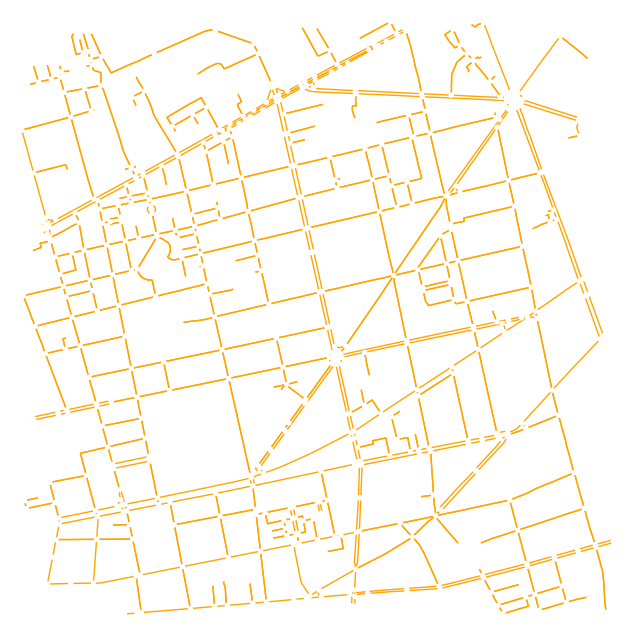

Mạng lưới giao thông bán kính 1km quanh UEH
Số lượng nút giao: 588 nút
Số lượng đoạn đường: 1335 đoạn
Chiều dài đường trung bình: 77.29 m


In [94]:
import osmnx as ox

toa_do_ueh = (10.761047, 106.668346)
mang_luoi = ox.graph_from_point(toa_do_ueh, dist=1000, network_type='drive')

fig, ax = ox.plot_graph(mang_luoi, bgcolor='white', node_size=15, edge_color='orange')

thong_ke = ox.basic_stats(mang_luoi)

print("Mạng lưới giao thông bán kính 1km quanh UEH")
print(f"Số lượng nút giao: {thong_ke['n']} nút")
print(f"Số lượng đoạn đường: {thong_ke['m']} đoạn")
print(f"Chiều dài đường trung bình: {thong_ke['street_length_avg']:.2f} m")

Bài 7

In [95]:
!pip install osmnx networkx

⏱️ Thời gian Dijkstra: 0.00067 giây
⏱️ Thời gian A* : 0.00071 giây

1.DIJKSTRA
- Ưu điểm: Đảm bảo 100% tìm được đường đi ngắn nhất. Dễ lập trình.
- Nhược điểm: Rất chậm và tốn bộ nhớ trên bản đồ lớn (như TP.HCM) vì thuật toán loang ra tìm kiếm ở mọi hướng, kể cả hướng đi ngược lại với đích đến.

2.A*
- Ưu điểm: Tốc độ cực nhanh. Nhờ có hàm Heuristic (ước lượng khoảng cách chim bay), A* biết đích đến ở hướng nào để ưu tiên tìm kiếm về hướng đó.
- Nhược điểm: Khó lập trình hơn. Nếu viết hàm Heuristic sai, máy sẽ tìm ra đường không tối ưu.
=>  Trong thực tế, các app như Google Maps, Grab bắt buộc phải dùng A* (hoặc bản nâng cao của nó) thay vì Dijkstra. Nếu dùng Dijkstra cho bản đồ thế giới hàng triệu nút giao, server sẽ bị treo hoặc mất vài phút mới tìm xong đường cho tài xế.



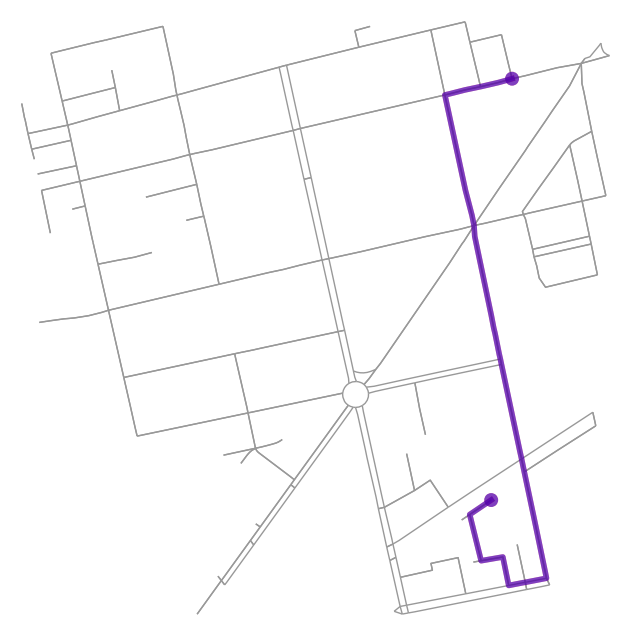

In [106]:
import osmnx as ox
import networkx as nx
import time

tam_ueh = (10.761047, 106.668346)
G = ox.graph_from_point(tam_ueh, dist=500, network_type='drive')

danh_sach_node = list(G.nodes())

diem_bat_dau = danh_sach_node[0]
diem_ket_thuc = danh_sach_node[-1]

#Chạy thuật toán DIJKSTRA

bat_dau_dijkstra = time.time()

tuyen_dijkstra = nx.shortest_path(G, diem_bat_dau, diem_ket_thuc, weight='length', method='dijkstra')

thoi_gian_dijkstra = time.time() - bat_dau_dijkstra
#Chạy thuật toán A*
def khoang_cach_chim_bay(u, v):
    x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
    x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
    return ((x1 - x2)**2 + (y1 - y2)**2)**0.5 * 111000 # Nhân 111000 để đổi từ Độ sang Mét

bat_dau_astar = time.time()
tuyen_astar = nx.astar_path(G, diem_bat_dau, diem_ket_thuc, heuristic=khoang_cach_chim_bay, weight='length')

thoi_gian_astar = time.time() - bat_dau_astar

print(f"⏱️ Thời gian Dijkstra: {thoi_gian_dijkstra:.5f} giây")
print(f"⏱️ Thời gian A* : {thoi_gian_astar:.5f} giây")
print("""
1.DIJKSTRA
- Ưu điểm: Đảm bảo 100% tìm được đường đi ngắn nhất. Dễ lập trình.
- Nhược điểm: Rất chậm và tốn bộ nhớ trên bản đồ lớn (như TP.HCM) vì thuật toán loang ra tìm kiếm ở mọi hướng, kể cả hướng đi ngược lại với đích đến.

2.A*
- Ưu điểm: Tốc độ cực nhanh. Nhờ có hàm Heuristic (ước lượng khoảng cách chim bay), A* biết đích đến ở hướng nào để ưu tiên tìm kiếm về hướng đó.
- Nhược điểm: Khó lập trình hơn. Nếu viết hàm Heuristic sai, máy sẽ tìm ra đường không tối ưu.
=>  Trong thực tế, các app như Google Maps, Grab bắt buộc phải dùng A* (hoặc bản nâng cao của nó) thay vì Dijkstra. Nếu dùng Dijkstra cho bản đồ thế giới hàng triệu nút giao, server sẽ bị treo hoặc mất vài phút mới tìm xong đường cho tài xế.
""")

fig, ax = ox.plot_graph_routes(
    G,
    routes=[tuyen_dijkstra, tuyen_astar],
    route_colors=['red', 'blue'],
    route_linewidth=4,
    node_size=0,
    bgcolor='white'
)

Bài 8

In [97]:
import folium
import random
from geopy.distance import geodesic

ueh_lat, ueh_lon = 10.761047, 106.668346
khach_hang = [{'id': f'Khách {i+1}', 'toa_do': (ueh_lat + random.uniform(-0.02, 0.02), ueh_lon + random.uniform(-0.02, 0.02))} for i in range(5)]
xe_cong_nghe = [{'id': f'Xe {i+1}', 'toa_do': (ueh_lat + random.uniform(-0.02, 0.02), ueh_lon + random.uniform(-0.02, 0.02)), 'trang_thai': 'rảnh'} for i in range(5)]
ghep_chuyen = []

for kh in khach_hang:
    xe_phu_hop = None
    khoang_cach_min = float('inf')
    for xe in xe_cong_nghe:
        if xe['trang_thai'] == 'rảnh':
            kc = geodesic(kh['toa_do'], xe['toa_do']).km
            if kc < khoang_cach_min:
                khoang_cach_min = kc
                xe_phu_hop = xe
    if xe_phu_hop:
        xe_phu_hop['trang_thai'] = 'bận'
        ghep_chuyen.append({
            'khach': kh,
            'xe': xe_phu_hop,
            'khoang_cach': round(khoang_cach_min, 2)
        })
m = folium.Map(location=[ueh_lat, ueh_lon], zoom_start=14)
for kh in khach_hang:
    folium.Marker(kh['toa_do'], popup=kh['id'], icon=folium.Icon(color='red', icon='user')).add_to(m)
for xe in xe_cong_nghe:
    folium.Marker(xe['toa_do'], popup=f"{xe['id']} ({xe['trang_thai']})", icon=folium.Icon(color='blue', icon='car')).add_to(m)
for chuyen in ghep_chuyen:
    toa_do_noi = [chuyen['khach']['toa_do'], chuyen['xe']['toa_do']]
    folium.PolyLine(
        locations=toa_do_noi,
        color='green',
        weight=3,
        dash_array='5, 5',
        tooltip=f"{chuyen['xe']['id']} đón {chuyen['khach']['id']} ({chuyen['khoang_cach']} km)"
    ).add_to(m)

m

Bài 9

In [98]:
import folium
import numpy as np
from sklearn.cluster import KMeans
ueh_lat, ueh_lon = 10.761047, 106.668346

np.random.seed(42)
lats = ueh_lat + np.random.uniform(-0.04, 0.04, 150)
lons = ueh_lon + np.random.uniform(-0.04, 0.04, 150)
du_lieu_khach_hang = np.column_stack((lats, lons))
so_tram = 3
kmeans = KMeans(n_clusters=so_tram, random_state=42, n_init=10)
kmeans.fit(du_lieu_khach_hang)
Nhan_cum = kmeans.labels_
Toa_do_kho = kmeans.cluster_centers_
m = folium.Map(location=[ueh_lat, ueh_lon], zoom_start=13)
mau_sac_cum = ['blue', 'green', 'purple']

for i in range(len(du_lieu_khach_hang)):
    folium.CircleMarker(
        location=[du_lieu_khach_hang[i][0], du_lieu_khach_hang[i][1]],
        radius=5,
        color=mau_sac_cum[Nhan_cum[i]],
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Đơn hàng thứ {i+1} (Khu vực {Nhan_cum[i]+1})"
    ).add_to(m)

for i, toa_do in enumerate(Toa_do_kho):
    folium.Marker(
        location=[toa_do[0], toa_do[1]],
        icon=folium.Icon(color='red', icon='star'),
        tooltip=f"📍 ĐỀ XUẤT: Vị trí đặt Trạm/Kho số {i+1}",
        popup=f"<b>Trạm Trung Chuyển {i+1}</b><br>Tọa độ: {round(toa_do[0],4)}, {round(toa_do[1],4)}"
    ).add_to(m)

m

Bài 10

In [105]:
import folium
from folium.plugins import HeatMap
import numpy as np
import random
ueh_lat, ueh_lon = 10.761047, 106.668346
m = folium.Map(location=[ueh_lat, ueh_lon], zoom_start=14)

np.random.seed(42)
du_lieu_giao_thong = []
vung_rui_ro_cao = []

for _ in range(200):
    lat = ueh_lat + np.random.uniform(-0.02, 0.02)
    lon = ueh_lon + np.random.uniform(-0.02, 0.02)
    mat_do_xe = random.randint(10, 100)
    yeu_to_su_co = random.randint(0, 100)
    diem_un_tac = (mat_do_xe * 0.7) + (yeu_to_su_co * 0.3)
    du_lieu_giao_thong.append([lat, lon, diem_un_tac])
    if diem_un_tac > 85:
        vung_rui_ro_cao.append([lat, lon])

HeatMap(du_lieu_giao_thong, radius=15, blur=10, gradient={0.4: 'green', 0.7: 'yellow', 1.0: 'red'}).add_to(m)
for vung in vung_rui_ro_cao[:5]:
    folium.CircleMarker(
        location=vung, radius=20, color='darkred', weight=2, fill=True,
        tooltip="⚠️ CẢNH BÁO: đang kẹt xe nghiêm trọng (vùng rủi ro)!"
    ).add_to(m)

diem_xuat_phat = [10.748, 106.655]
diem_dich_den = [10.772, 106.678]
tuyen_kẹt_xe = [diem_xuat_phat, [ueh_lat, ueh_lon], diem_dich_den]
folium.PolyLine(tuyen_kẹt_xe, color='red', weight=4, dash_array='5, 5', tooltip="Tuyến cũ: Ngắn nhất nhưng đang kẹt cứng").add_to(m)
tuyen_de_xuat = [diem_xuat_phat, [10.765, 106.650], [10.775, 106.665], diem_dich_den]
folium.PolyLine(tuyen_de_xuat, color='green', weight=6, tooltip="TUYẾN ĐỀ XUẤT: Lộ trình đi vòng né kẹt xe").add_to(m)
folium.Marker(diem_xuat_phat, icon=folium.Icon(color='black', icon='play')).add_to(m)
folium.Marker(diem_dich_den, icon=folium.Icon(color='black', icon='stop')).add_to(m)
m

Bài 11

In [100]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

np.random.seed(99)
so_luong = 1500

diem_nong = {
    'Khu Sinh Viên (Q10)': [10.761, 106.668],
    'Khu Dân Cư (Q7)': [10.730, 106.720]
}

du_lieu = []
for _ in range(so_luong):
    gio_trong_ngay = np.random.randint(0, 24)
    khu_vuc = 'Khu Sinh Viên (Q10)' if np.random.rand() > 0.5 else 'Khu Dân Cư (Q7)'

    lat = diem_nong[khu_vuc][0] + np.random.normal(0, 0.015)
    lon = diem_nong[khu_vuc][1] + np.random.normal(0, 0.015)

    if khu_vuc == 'Khu Sinh Viên (Q10)':
        nhu_cau = 100 - abs(gio_trong_ngay - 17) * 6 + np.random.randint(0, 15)
    else:
        nhu_cau = 100 - abs(gio_trong_ngay - 7) * 6 + np.random.randint(0, 15)

    du_lieu.append([lat, lon, gio_trong_ngay, max(0, nhu_cau)])

df_xe = pd.DataFrame(du_lieu, columns=['Vi_do', 'Kinh_do', 'Gio', 'Nhu_cau'])

X_train = df_xe[['Vi_do', 'Kinh_do', 'Gio']]
y_train = df_xe['Nhu_cau']

mo_hinh = RandomForestRegressor(n_estimators=50, random_state=99)
mo_hinh.fit(X_train, y_train)

gio_kiem_tra = int(input('Nhập giờ bạn muốn xem dự báo kẹt xe (0-23): '))

df_du_doan = df_xe.copy()
df_du_doan['Gio'] = gio_kiem_tra
df_du_doan['Nhu_cau_AI_doan'] = mo_hinh.predict(df_du_doan[['Vi_do', 'Kinh_do', 'Gio']])

m = folium.Map(location=[10.745, 106.690], zoom_start=13)

heat_data = df_du_doan[['Vi_do', 'Kinh_do', 'Nhu_cau_AI_doan']].values.tolist()

HeatMap(
    heat_data,
    radius=20,
    blur=12,
    gradient={0.2: 'blue', 0.6: 'yellow', 1: 'red'}
).add_to(m)
print(f"BẢN ĐỒ DỰ BÁO NHU CẦU GỌI XE LÚC {gio_kiem_tra}:00")

m

Nhập giờ bạn muốn xem dự báo kẹt xe (0-23): 12
BẢN ĐỒ DỰ BÁO NHU CẦU GỌI XE LÚC 12:00


Nhu cầu giữa các khu vực có sự khác biệt rõ rệt theo thời gian. Khu dân cư (Q7) thường tăng cao vào buổi sáng do nhu cầu đi làm, trong khi khu sinh viên (Q10) lại đạt đỉnh vào buổi chiều khi tan học. Điều này cho thấy việc điều phối cần linh hoạt: hệ thống nên chủ động điều hướng tài xế đến đúng khu vực trước giờ cao điểm và có thể áp dụng surge pricing tại các vùng có nhu cầu cao để cân bằng cung – cầu.

Bài 12

In [101]:
import folium
import pandas as pd
import numpy as np
from scipy.spatial import distance

np.random.seed(42)

cac_kho = {
    'Kho Tan Binh': [10.8015, 106.6521],
    'Kho Quan 7': [10.7339, 106.7180]
}

so_luong_diem = 20
diem_khach_hang = np.random.uniform(low=[10.70, 106.60], high=[10.85, 106.75], size=(so_luong_diem, 2))

def vach_tuyen_duong(diem_xuat_phat, danh_sach_giao):
    lo_trinh = [diem_xuat_phat]
    cac_diem_chua_giao = danh_sach_giao.tolist()
    diem_hien_tai = diem_xuat_phat

    while cac_diem_chua_giao:
        khoang_cach_mang = [distance.euclidean(diem_hien_tai, p) for p in cac_diem_chua_giao]
        vi_tri_gan_nhat = np.argmin(khoang_cach_mang)
        diem_tiep_theo = cac_diem_chua_giao.pop(vi_tri_gan_nhat)

        lo_trinh.append(diem_tiep_theo)
        diem_hien_tai = diem_tiep_theo

    lo_trinh.append(diem_xuat_phat)
    return lo_trinh

don_tan_binh = []
don_quan_7 = []

for diem in diem_khach_hang:
    kc_tb = distance.euclidean(diem, cac_kho['Kho Tan Binh'])
    kc_q7 = distance.euclidean(diem, cac_kho['Kho Quan 7'])
    if kc_tb < kc_q7:
        don_tan_binh.append(diem)
    else:
        don_quan_7.append(diem)

tuyen_tan_binh = vach_tuyen_duong(cac_kho['Kho Tan Binh'], np.array(don_tan_binh))
tuyen_quan_7 = vach_tuyen_duong(cac_kho['Kho Quan 7'], np.array(don_quan_7))

ban_do = folium.Map(location=[10.77, 106.68], zoom_start=12)

folium.Marker(cac_kho['Kho Tan Binh'], tooltip="Kho Tan Binh", icon=folium.Icon(color='green', icon='home')).add_to(ban_do)
folium.Marker(cac_kho['Kho Quan 7'], tooltip="Kho Quan 7", icon=folium.Icon(color='orange', icon='home')).add_to(ban_do)

folium.PolyLine(tuyen_tan_binh, color="green", weight=3, opacity=0.8).add_to(ban_do)
folium.PolyLine(tuyen_quan_7, color="orange", weight=3, opacity=0.8).add_to(ban_do)

for p in diem_khach_hang:
    folium.CircleMarker(location=p, radius=4, color='black', fill=True).add_to(ban_do)

ban_do

Bài 13


In [102]:
import folium
import numpy as np

np.random.seed(2026)
dashboard = folium.Map(location=[10.77, 106.68], zoom_start=13)

lop_vung = folium.FeatureGroup(name="Vùng Phân Phối (Areas)")
folium.Circle(location=[10.7769, 106.7009], radius=1500, color='blue', fill=True, fill_opacity=0.15, tooltip="Zone 1: Khu vực Quận 1").add_to(lop_vung)
folium.Circle(location=[10.7610, 106.6683], radius=2200, color='green', fill=True, fill_opacity=0.15, tooltip="Zone 2: Khu vực Quận 10").add_to(lop_vung)

lop_diem = folium.FeatureGroup(name="Điểm Giao Dịch & Khách Hàng (Points)")
kho_trung_tam = [10.7769, 106.7009]
kho_chi_nhanh = [10.7610, 106.6683]

folium.Marker(location=kho_trung_tam, icon=folium.Icon(color='red', icon='star'), tooltip="Kho Tổng Q1").add_to(lop_diem)
folium.Marker(location=kho_chi_nhanh, icon=folium.Icon(color='orange', icon='star'), tooltip="Kho Vệ Tinh Q10").add_to(lop_diem)

for _ in range(8):
    lat = 10.7769 + np.random.uniform(-0.01, 0.01)
    lon = 106.7009 + np.random.uniform(-0.01, 0.01)
    folium.CircleMarker(location=[lat, lon], radius=6, color='darkblue', fill=True, fill_opacity=0.8).add_to(lop_diem)

for _ in range(12):
    lat = 10.7610 + np.random.uniform(-0.015, 0.015)
    lon = 106.6683 + np.random.uniform(-0.015, 0.015)
    folium.CircleMarker(location=[lat, lon], radius=6, color='darkgreen', fill=True, fill_opacity=0.8).add_to(lop_diem)

lop_tuyen = folium.FeatureGroup(name="Tuyến Vận Chuyển Lõi (Routes)")
tuyen_lien_kho = [kho_trung_tam, [10.765, 106.685], kho_chi_nhanh]
folium.PolyLine(locations=tuyen_lien_kho, color='purple', weight=5, dash_array='10, 10', tooltip="Tuyến Tiếp Vận Liên Kho (Mỗi ngày 2 chuyến)").add_to(lop_tuyen)

dashboard.add_child(lop_vung)
dashboard.add_child(lop_diem)
dashboard.add_child(lop_tuyen)

folium.LayerControl(position='topright').add_to(dashboard)

dashboard

Bài 14

In [103]:
import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta

def xay_dung_lich_trinh(danh_sach_toa_do, mau_sac_xe, gio_xuat_phat):
    khoi_du_lieu = []
    thoi_gian_diem_nut = gio_xuat_phat

    for i in range(len(danh_sach_toa_do) - 1):
        toa_do_1 = danh_sach_toa_do[i]
        toa_do_2 = danh_sach_toa_do[i+1]
        thoi_gian_den_noi = thoi_gian_diem_nut + timedelta(minutes=10)

        doan_duong = {
            'type': 'Feature',
            'geometry': {
                'type': 'LineString',
                'coordinates': [[toa_do_1[1], toa_do_1[0]], [toa_do_2[1], toa_do_2[0]]]
            },
            'properties': {
                'times': [thoi_gian_diem_nut.isoformat(), thoi_gian_den_noi.isoformat()],
                'style': {'color': mau_sac_xe, 'weight': 5, 'opacity': 0.9}
            }
        }
        khoi_du_lieu.append(doan_duong)
        thoi_gian_diem_nut = thoi_gian_den_noi

    return khoi_du_lieu

bando_thoigian = folium.Map(location=[10.78, 106.68], zoom_start=13)
moc_khoi_hanh = datetime.now().replace(hour=7, minute=30, second=0, microsecond=0)

tuyen_xe_1 = [[10.8015, 106.7112], [10.7950, 106.7050], [10.7850, 106.6950], [10.7760, 106.7010], [10.7700, 106.7050]]
tuyen_xe_2 = [[10.7610, 106.6683], [10.7650, 106.6750], [10.7700, 106.6850], [10.7750, 106.6900], [10.7800, 106.6950]]

du_lieu_xe_1 = xay_dung_lich_trinh(tuyen_xe_1, 'green', moc_khoi_hanh)
du_lieu_xe_2 = xay_dung_lich_trinh(tuyen_xe_2, 'orange', moc_khoi_hanh)

TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': du_lieu_xe_1 + du_lieu_xe_2},
    period='PT1M',
    add_last_point=True,
    auto_play=True,
    loop=True,
    date_options='HH:mm'
).add_to(bando_thoigian)

folium.Marker(tuyen_xe_1[0], icon=folium.Icon(color='green', icon='play')).add_to(bando_thoigian)
folium.Marker(tuyen_xe_2[0], icon=folium.Icon(color='orange', icon='play')).add_to(bando_thoigian)

bando_thoigian

Bài 15

Bài này em đã ứng dụng AI để phân tích dữ liệu không gian, giúp các chuỗi cửa hàng (như trà sữa, bán lẻ) tìm ra những vị trí mở chi nhánh có khả năng sinh lời cao nhất. Mục tiêu là xác định Top 3 "Vị trí Vàng" tại TP.HCM dựa trên sự cân bằng giữa nhu cầu thị trường và áp lực cạnh tranh.

In [107]:
import folium
from folium.plugins import HeatMap, Fullscreen
import numpy as np
import pandas as pd

n_scan = 2500
scan_lats = np.random.uniform(10.72, 10.82, n_scan)
scan_lons = np.random.uniform(106.63, 106.73, n_scan)

df_organic_scan = pd.DataFrame({'lat': scan_lats, 'lon': scan_lons})
df_organic_scan['pop'] = 4000
df_organic_scan['comp'] = df_organic_scan.apply(lambda r: get_comp_score(r['lat'], r['lon']), axis=1)
df_organic_scan['rev_pred'] = ai_model.predict(df_organic_scan[['lat', 'lon', 'pop', 'comp']])

m_final = folium.Map(location=[10.77, 106.68], zoom_start=13)

data_nhiet = df_organic_scan[['lat', 'lon', 'rev_pred']].values.tolist()
max_revenue = float(df_organic_scan['rev_pred'].max())

HeatMap(
    data_nhiet,
    radius=25,
    blur=20,
    min_opacity=0.2,
    max_val=max_revenue,
    gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1.0: 'red'}
).add_to(m_final)

for pt in competitors:
    folium.Marker([pt[0], pt[1]], icon=folium.Icon(color='darkred', icon='remove-sign')).add_to(m_final)

for i, r in top_spots.iterrows():
    folium.Marker(
        [r['lat'], r['lon']],
        icon=folium.Icon(color='orange', icon='star', icon_color='white'),
        tooltip="ĐỊA ĐIỂM ĐỀ XUẤT"
    ).add_to(m_final)

Fullscreen().add_to(m_final)
m_final

/tmp/ipykernel_8360/2788625383.py:20: UserWarning: The `max_val` parameter is no longer necessary. The largest intensity is calculated automatically.
  HeatMap(
